In [1]:
import os
import glob
import shutil
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
from sklearn.model_selection import GroupShuffleSplit
import torchvision.transforms as T
import cv2

# Load Dataset

In [2]:
import os

# Dataset path
dataset_path = "/kaggle/input/datasets/mdmoonrahmannayem/diabates-retinopathy/Augmented Dataset"

# Dictionary to store class counts
class_counts = {}

# Count images in each class
for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):

        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

        class_counts[class_name] = len(images)

# Print total classes
print("Total Classes:", len(class_counts))
print()

# Print image count per class
print("Image Count Per Class:")
for class_name, count in class_counts.items():
    print(f"{class_name} : {count} images")

# Calculate total images
total_images = sum(class_counts.values())

print("\nClass Percentage Distribution:")

# Print percentage of each class
for class_name, count in class_counts.items():
    percentage = (count / total_images) * 100
    print(f"{class_name} : {percentage:.2f}%")

Total Classes: 2

Image Count Per Class:
Healthy : 2676 images
Diabetic Retinopathy : 3444 images

Class Percentage Distribution:
Healthy : 43.73%
Diabetic Retinopathy : 56.27%


# Sample Images Visualization

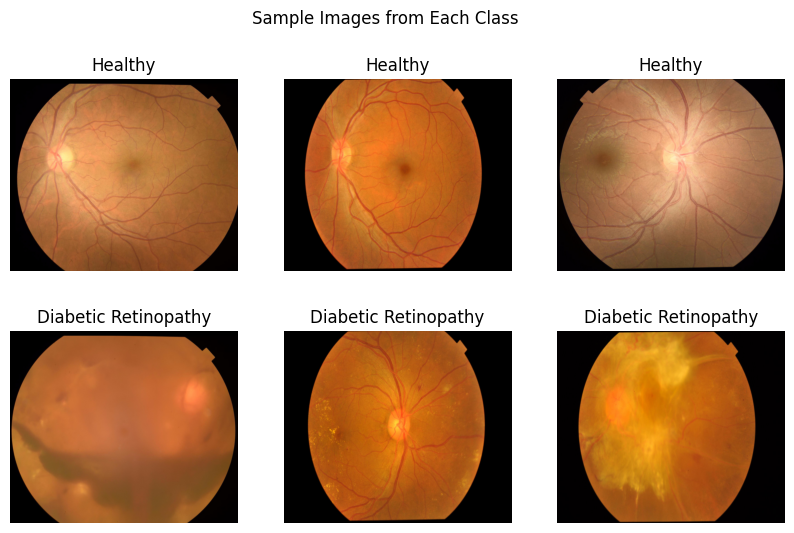

In [3]:
import random
classes = os.listdir(dataset_path)

plt.figure(figsize=(10,6))

plot_index = 1

for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    images = [img for img in os.listdir(class_path) if img.endswith((".png",".jpg",".jpeg"))]

    samples = random.sample(images, min(3,len(images)))

    for img_name in samples:

        img_path = os.path.join(class_path,img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2,3,plot_index)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

plt.suptitle("Sample Images from Each Class")

plt.show()

# Image Resolution Distribution

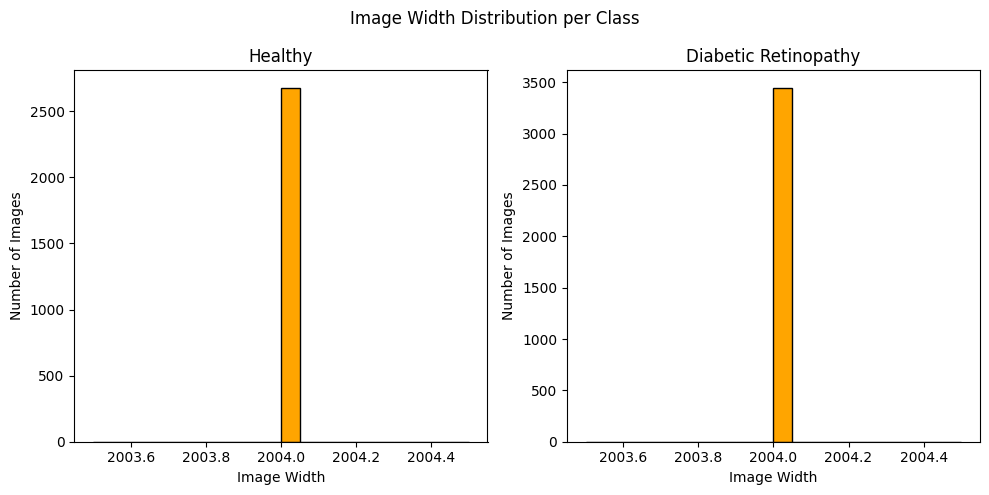

In [4]:
class_widths = {}

for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):

        widths = []

        for img_name in os.listdir(class_path):

            img_path = os.path.join(class_path, img_name)

            if img_name.lower().endswith((".png",".jpg",".jpeg")):
                img = Image.open(img_path)
                w, h = img.size
                widths.append(w)

        class_widths[class_name] = widths


# Histogram plotting
num_classes = len(class_widths)

plt.figure(figsize=(10,5))

for i,(class_name,widths) in enumerate(class_widths.items()):

    plt.subplot(1, num_classes, i+1)

    plt.hist(widths, bins=20, color="orange", edgecolor="black")

    plt.title(class_name)
    plt.xlabel("Image Width")
    plt.ylabel("Number of Images")

plt.suptitle("Image Width Distribution per Class")

plt.tight_layout()
plt.show()

# Brightness Analysis

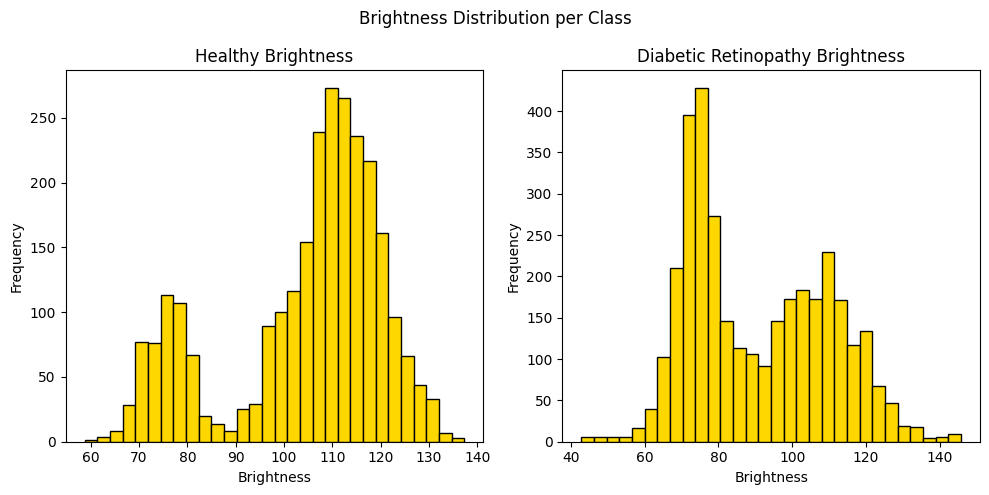

In [5]:
class_brightness = {}

for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):

        brightness_values = []

        for img_name in os.listdir(class_path):

            img_path = os.path.join(class_path, img_name)

            if img_name.lower().endswith((".png",".jpg",".jpeg")):

                img = cv2.imread(img_path)
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                brightness = np.mean(gray)

                brightness_values.append(brightness)

        class_brightness[class_name] = brightness_values


# Plot histograms
num_classes = len(class_brightness)

plt.figure(figsize=(10,5))

for i,(class_name,values) in enumerate(class_brightness.items()):

    plt.subplot(1,num_classes,i+1)

    plt.hist(values, bins=30, color="gold", edgecolor="black")

    plt.title(f"{class_name} Brightness")
    plt.xlabel("Brightness")
    plt.ylabel("Frequency")

plt.suptitle("Brightness Distribution per Class")

plt.tight_layout()
plt.show()

# RGB Color Histogram

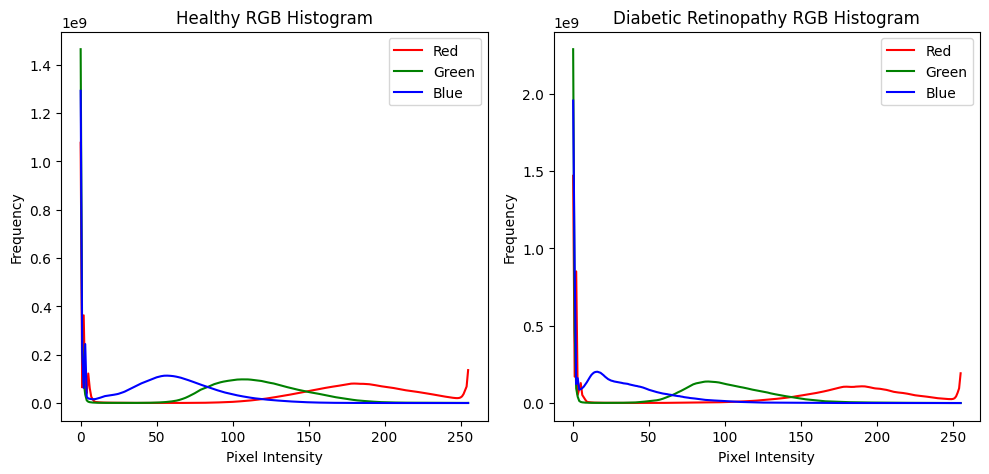

In [6]:
classes = os.listdir(dataset_path)

plt.figure(figsize=(10,5))

for idx, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    r_hist = np.zeros(256)
    g_hist = np.zeros(256)
    b_hist = np.zeros(256)

    for img_name in os.listdir(class_path):

        if img_name.lower().endswith((".png",".jpg",".jpeg")):

            img_path = os.path.join(class_path,img_name)

            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            r_hist += cv2.calcHist([img],[0],None,[256],[0,256]).flatten()
            g_hist += cv2.calcHist([img],[1],None,[256],[0,256]).flatten()
            b_hist += cv2.calcHist([img],[2],None,[256],[0,256]).flatten()

    plt.subplot(1,2,idx+1)

    plt.plot(r_hist,color='red',label="Red")
    plt.plot(g_hist,color='green',label="Green")
    plt.plot(b_hist,color='blue',label="Blue")

    plt.title(f"{class_name} RGB Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.legend()

plt.tight_layout()
plt.show()

# Sharpness Analysis (Blur Detection)

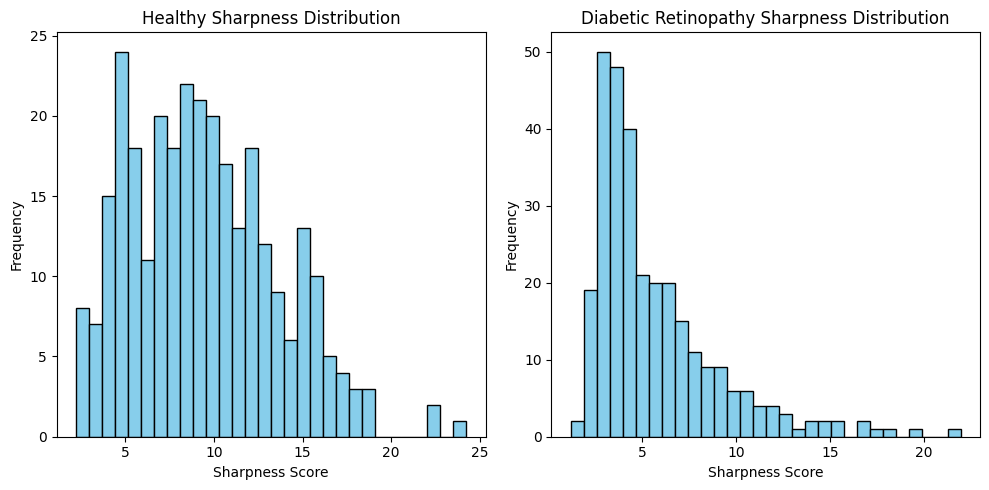

In [7]:
import random
def laplacian_variance(image_path):

    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    return cv2.Laplacian(gray, cv2.CV_64F).var()


classes = os.listdir(dataset_path)

plt.figure(figsize=(10,5))

for idx, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    images = [img for img in os.listdir(class_path)
              if img.lower().endswith((".png",".jpg",".jpeg"))]

    # only sample 300 images
    images = random.sample(images, min(300,len(images)))

    sharpness_scores = []

    for img_name in images:

        img_path = os.path.join(class_path, img_name)

        score = laplacian_variance(img_path)

        sharpness_scores.append(score)

    plt.subplot(1,2,idx+1)

    plt.hist(sharpness_scores, bins=30, color="skyblue", edgecolor="black")

    plt.title(f"{class_name} Sharpness Distribution")
    plt.xlabel("Sharpness Score")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Corrupted Image Detection

In [8]:
corrupted_counts = {}

for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):

        corrupted_images = []

        for img_name in os.listdir(class_path):

            if img_name.lower().endswith((".png",".jpg",".jpeg")):

                img_path = os.path.join(class_path, img_name)

                try:
                    img = cv2.imread(img_path)

                    if img is None:
                        corrupted_images.append(img_path)

                except:
                    corrupted_images.append(img_path)

        corrupted_counts[class_name] = len(corrupted_images)


# Print result
for class_name, count in corrupted_counts.items():
    print(f"{class_name} corrupted images:", count)

Healthy corrupted images: 0
Diabetic Retinopathy corrupted images: 0


# Image Resizing + Normalization (Preprocessing)

In [9]:
IMG_SIZE = 224

processed_images = []
labels = []

classes = os.listdir(dataset_path)

for label, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    for img_name in os.listdir(class_path):

        if img_name.lower().endswith((".png",".jpg",".jpeg")):

            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # resize
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # normalize
            img = img / 255.0

            processed_images.append(img)
            labels.append(label)


processed_images = np.array(processed_images)
labels = np.array(labels)

print("Processed Images Shape:", processed_images.shape)
print("Labels Shape:", labels.shape)
print("Classes:", classes)

Processed Images Shape: (6120, 224, 224, 3)
Labels Shape: (6120,)
Classes: ['Healthy', 'Diabetic Retinopathy']


# Empty Images and Broken Images

In [10]:
empty_count = {}
broken_count = {}

for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):

        empty = 0
        broken = 0

        for img_name in os.listdir(class_path):

            if img_name.lower().endswith((".png",".jpg",".jpeg")):

                img_path = os.path.join(class_path, img_name)

                img = cv2.imread(img_path)

                # Empty image check
                if img is not None and img.size == 0:
                    empty += 1

                # Broken file check
                try:
                    Image.open(img_path)
                except:
                    broken += 1


        empty_count[class_name] = empty
        broken_count[class_name] = broken


# Result print
print("Empty Images:")
for k,v in empty_count.items():
    print(k,":",v)

print("\nBroken Images:")
for k,v in broken_count.items():
    print(k,":",v)

Empty Images:
Healthy : 0
Diabetic Retinopathy : 0

Broken Images:
Healthy : 0
Diabetic Retinopathy : 0


# Pixel Intensity Distribution

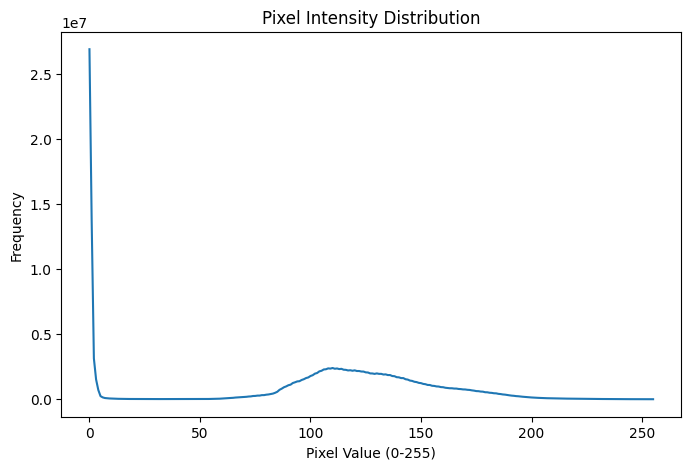

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

dataset_path = "/kaggle/input/datasets/mdmoonrahmannayem/diabates-retinopathy/Augmented Dataset"

# histogram accumulator
hist_total = np.zeros(256)

for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):

        images = os.listdir(class_path)

        # take only 30 random images per class
        sample_images = random.sample(images, min(30, len(images)))

        for img_name in sample_images:

            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                hist = cv2.calcHist([img],[0],None,[256],[0,256])
                hist_total += hist.flatten()

plt.figure(figsize=(8,5))

plt.plot(hist_total)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value (0-255)")
plt.ylabel("Frequency")

plt.show()

# Dataset Diversity Visualization

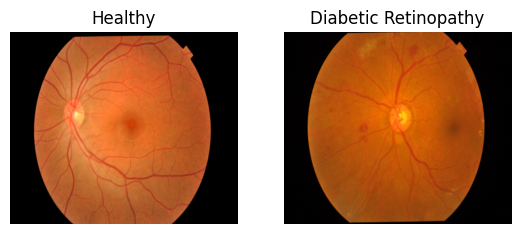

In [2]:
import cv2
import random
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for i, class_name in enumerate(os.listdir(dataset_path)):

    class_path = os.path.join(dataset_path, class_name)

    images = os.listdir(class_path)

    img_name = random.choice(images)

    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(class_name)
    plt.axis("off")

plt.show()

# Duplicate Image Detection

In [6]:
import hashlib

hashes = set()
duplicates = 0

for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    images = os.listdir(class_path)[:200]   # sample check

    for img_name in images:

        img_path = os.path.join(class_path, img_name)

        with open(img_path,'rb') as f:

            img_hash = hashlib.md5(f.read()).hexdigest()

        if img_hash in hashes:
            duplicates += 1
        else:
            hashes.add(img_hash)

print("Duplicate Images Found:", duplicates)

Duplicate Images Found: 0


# Data Augmentation Visualization

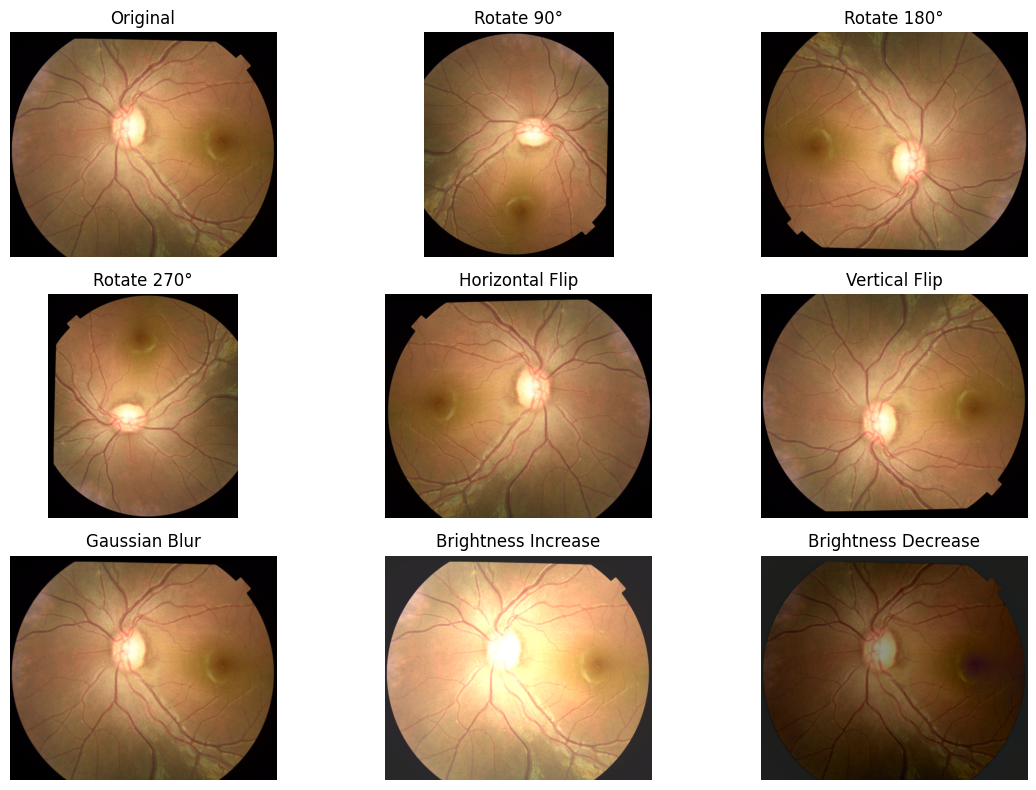

In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

dataset_path = "/kaggle/input/datasets/mdmoonrahmannayem/diabates-retinopathy/Augmented Dataset"

# random image
class_name = os.listdir(dataset_path)[0]
class_path = os.path.join(dataset_path, class_name)

img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# augmentations
rotate90 = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
rotate180 = cv2.rotate(img, cv2.ROTATE_180)
rotate270 = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)

flip_h = cv2.flip(img,1)
flip_v = cv2.flip(img,0)

blur = cv2.GaussianBlur(img,(9,9),0)

bright = cv2.convertScaleAbs(img, alpha=1.3, beta=40)
dark = cv2.convertScaleAbs(img, alpha=0.7, beta=-30)

images = [
img,
rotate90,
rotate180,
rotate270,
flip_h,
flip_v,
blur,
bright,
dark
]

labels = [
"Original",
"Rotate 90°",
"Rotate 180°",
"Rotate 270°",
"Horizontal Flip",
"Vertical Flip",
"Gaussian Blur",
"Brightness Increase",
"Brightness Decrease"
]

plt.figure(figsize=(12,8))

for i in range(len(images)):
    
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()